In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
data=pd.read_csv('silver_prices_data.csv')

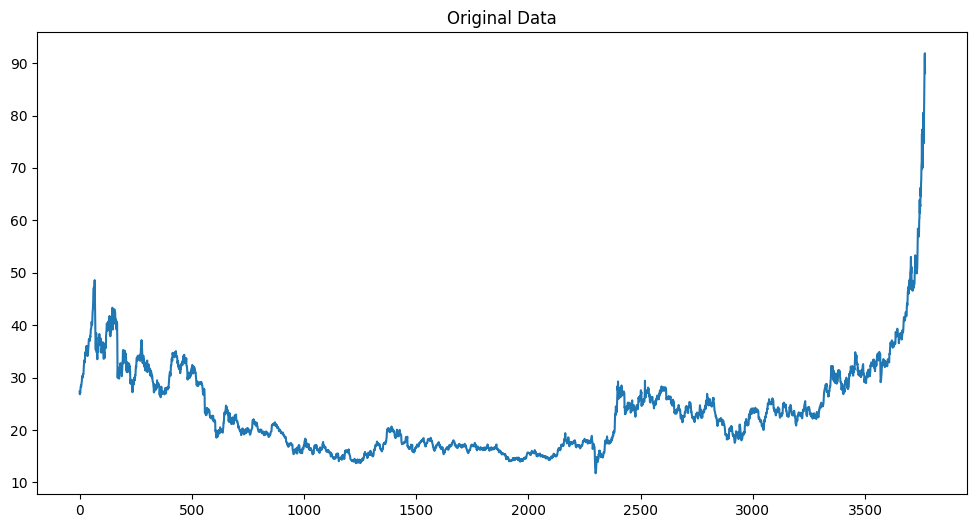

In [ ]:
N=1000
plt.rcParams['figure.figsize'] = [12, 6]
X=data['Price']
plt.plot(X)
plt.title('Original Data')
plt.show()


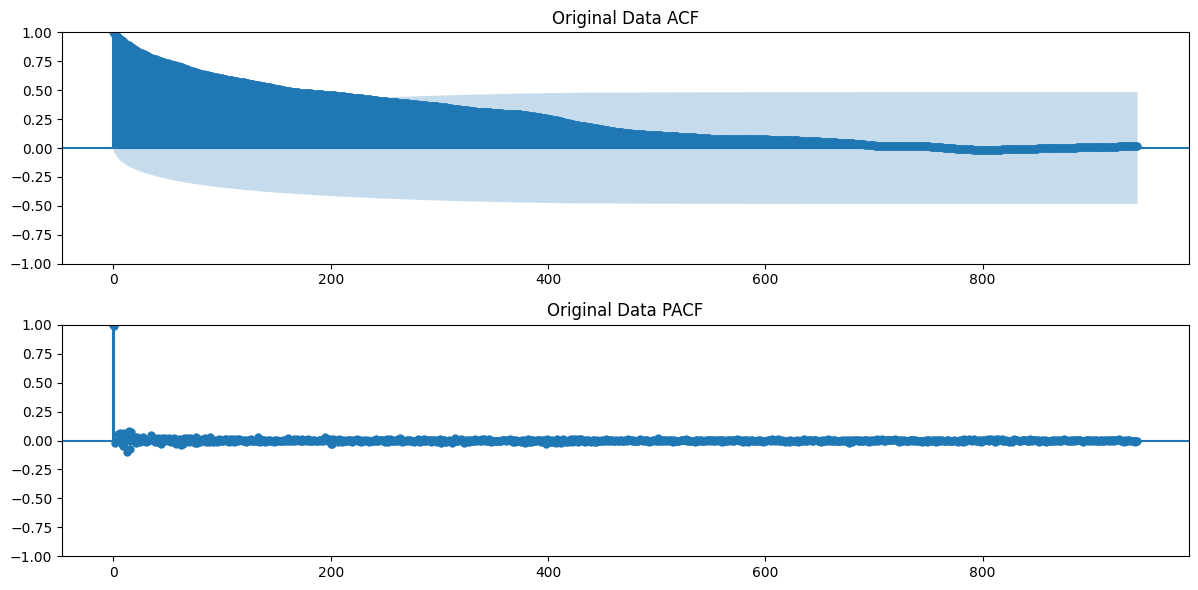

In [ ]:
plt.subplot(2, 1, 1)
plot_acf(X, lags=len(X)/4, ax=plt.gca())
plt.title('Original Data ACF')
plt.subplot(2, 1, 2)
plot_pacf(X, lags=len(X)/4, ax=plt.gca())
plt.title('Original Data PACF')
plt.tight_layout()
plt.show()

In [ ]:
arma11_model = ARIMA(X, order=(1, 0, 1)).fit()
phi1_arma11 = arma11_model.params['ar.L1']
theta1_arma11 = arma11_model.params['ma.L1']

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


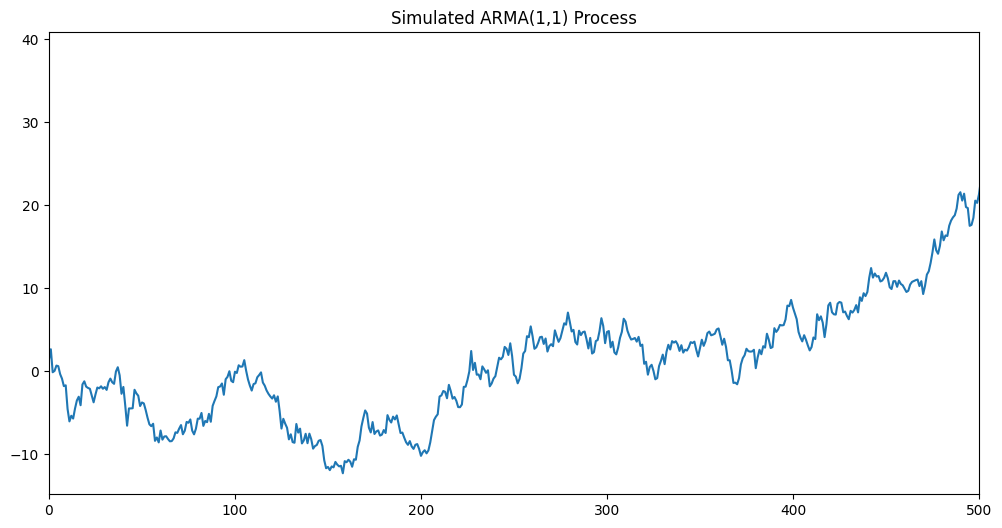

In [ ]:
ar1 = np.array([1, -phi1_arma11])
ma1 = np.array([1, theta1_arma11])
ARMA_1 = ArmaProcess(ar1, ma1).generate_sample(nsample=N)
plt.plot(ARMA_1)
plt.title('Simulated ARMA(1,1) Process')
plt.xlim([0, 500])
plt.show()

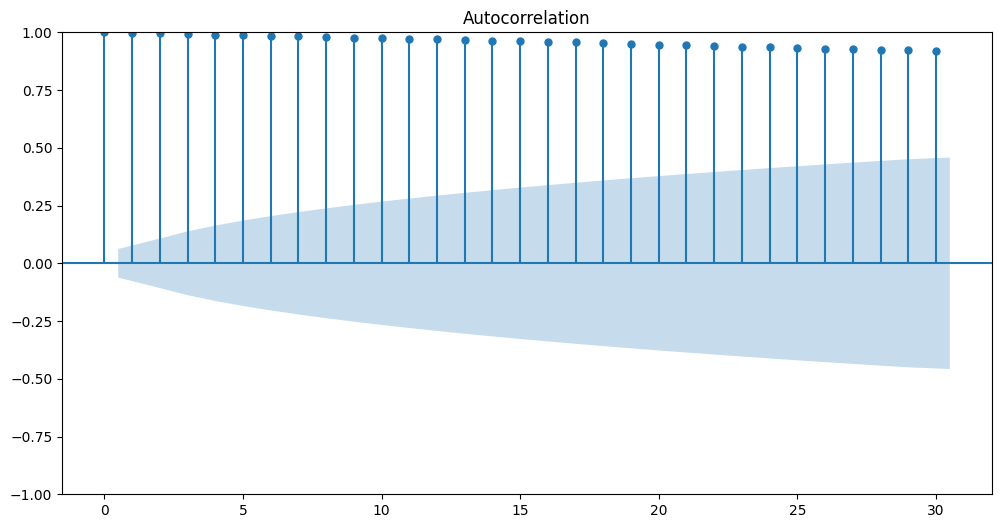

In [ ]:
plot_acf(ARMA_1)
plt.show()


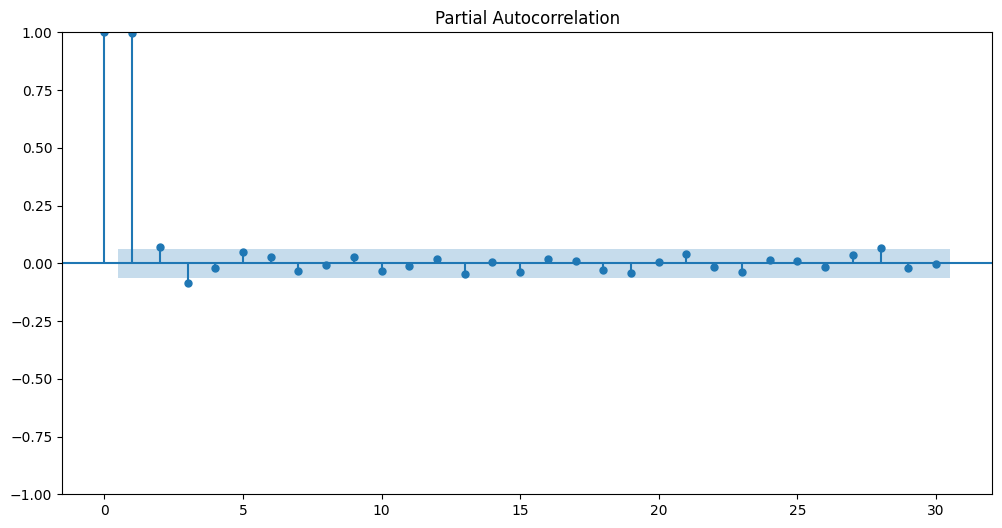

In [ ]:
plot_pacf(ARMA_1)
plt.show()

In [ ]:
arma22_model = ARIMA(X, order=(2, 0, 2)).fit()
phi1_arma22 = arma22_model.params['ar.L1']
phi2_arma22 = arma22_model.params['ar.L2']
theta1_arma22 = arma22_model.params['ma.L1']
theta2_arma22 = arma22_model.params['ma.L2']


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


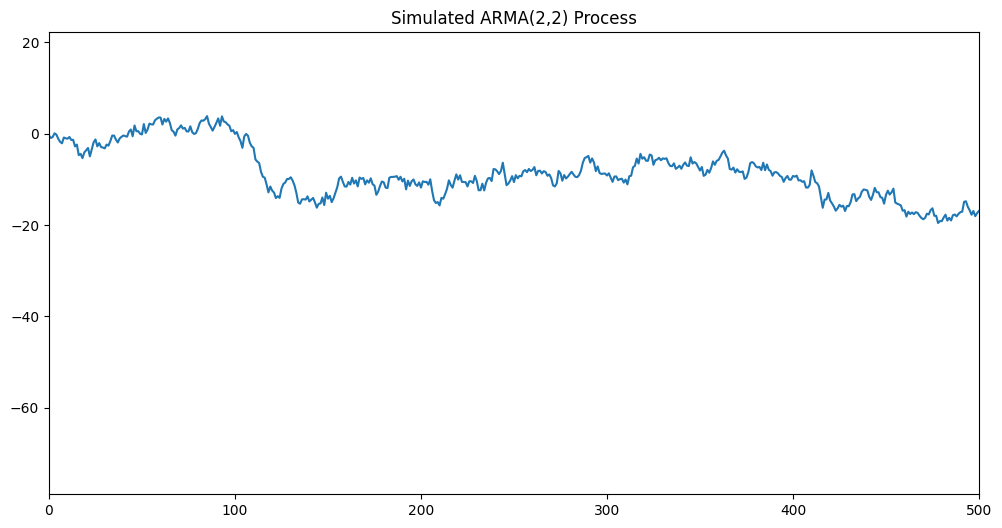

In [ ]:
ar2 = np.array([1, -phi1_arma22, -phi2_arma22])
ma2 = np.array([1, theta1_arma22, theta2_arma22])
ARMA_2 = ArmaProcess(ar2, ma2).generate_sample(nsample=N*10)
plt.plot(ARMA_2)
plt.title('Simulated ARMA(2,2) Process')
plt.xlim([0, 500])
plt.show()

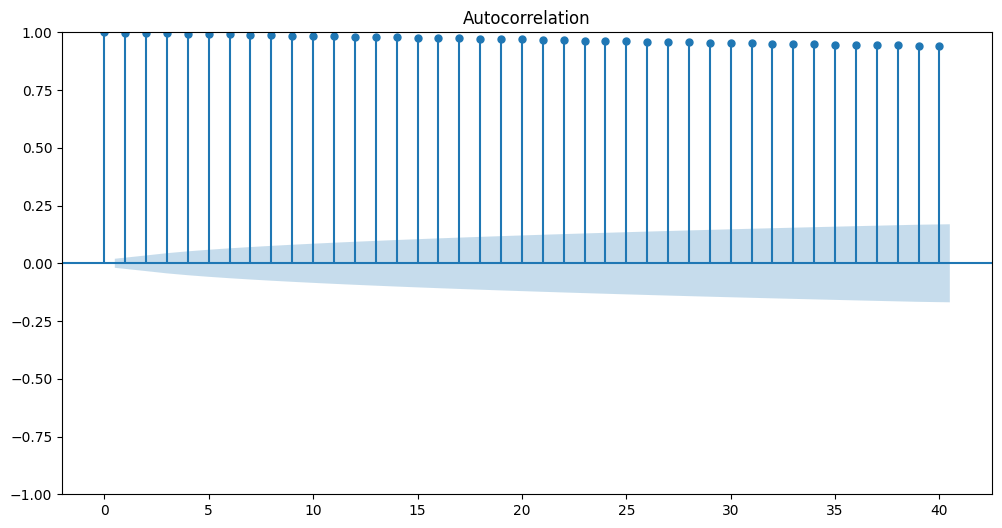

In [ ]:
plot_acf(ARMA_2)
plt.show()


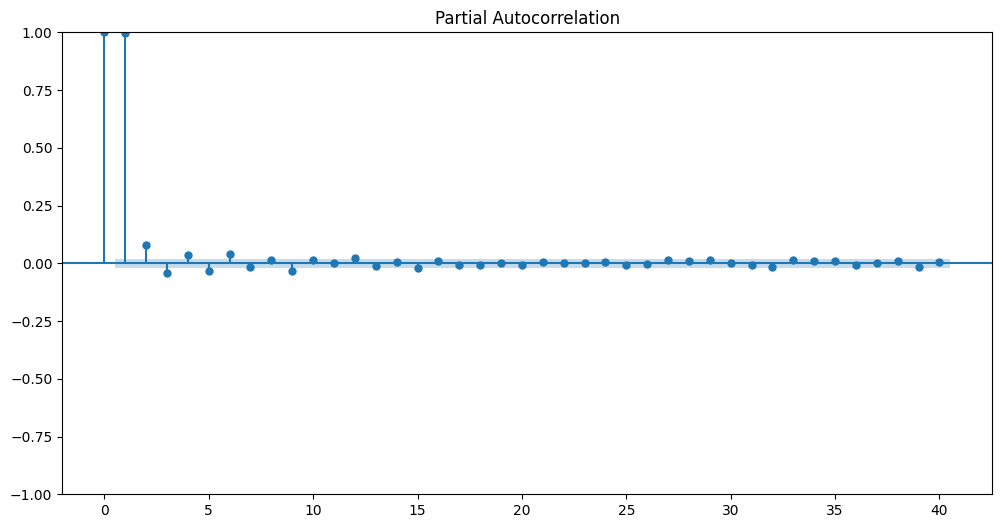

In [ ]:
plot_pacf(ARMA_2)
plt.show()